Kaggle

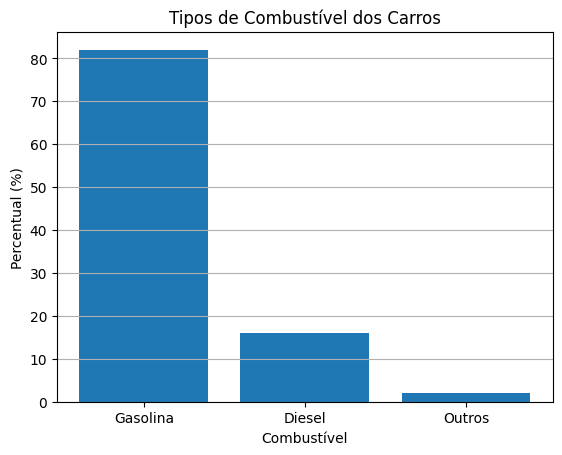

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

combustivel = ['Gasolina', 'Diesel', 'Outros']
quantidade = [82, 16, 2]

plt.bar(combustivel, quantidade)

plt.xlabel('Combustível')
plt.ylabel('Percentual (%)')
plt.title('Tipos de Combustível dos Carros')

plt.grid(axis='y')
plt.show()

In [14]:
#Adicionando biblioteca publica no Kaggle, melhor funcionalidade

Markdown 
1. Ponto 1
2. Ponto 2
3. Ponto 3

Agora vou usar uma base de dados do Kaggle

In [32]:
import pandas as pd

df = pd.read_csv('/kaggle/input/notebooks/asokraju/auto-mpg-dataset/auto_v1.csv')

df.head() #Explorando o dataset de dados dos carros

,Unnamed: 0.1,Unnamed: 0,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,0,0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,1,1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,2,2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,3,3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,4,4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


Ele se baseia em uma predição para o consumo de um carro, mediante vários fatores como peso, motor, estrutura...

In [34]:
# Dimensões
df.shape

(398, 11)

In [35]:
# Tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  398 non-null    int64  
 1   Unnamed: 0    398 non-null    int64  
 2   mpg           398 non-null    float64
 3   cylinders     398 non-null    int64  
 4   displacement  398 non-null    float64
 5   horsepower    392 non-null    float64
 6   weight        398 non-null    float64
 7   acceleration  398 non-null    float64
 8   model_year    398 non-null    int64  
 9   origin        398 non-null    int64  
 10  car_name      398 non-null    object 
dtypes: float64(5), int64(5), object(1)
memory usage: 34.3+ KB


In [36]:
# Estatísticas
df.describe()

,Unnamed: 0.1,Unnamed: 0,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,198.500000,198.500000,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,115.036951,115.036951,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,0.000000,0.000000,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,99.250000,99.250000,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,198.500000,198.500000,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,297.750000,297.750000,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,397.000000,397.000000,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [37]:
# Valores ausentes no dataset
df.isnull().sum()


Unnamed: 0.1    0
Unnamed: 0      0
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [38]:
# Colunas
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'mpg', 'cylinders', 'displacement',
       'horsepower', 'weight', 'acceleration', 'model_year', 'origin',
       'car_name'],
      dtype='object')

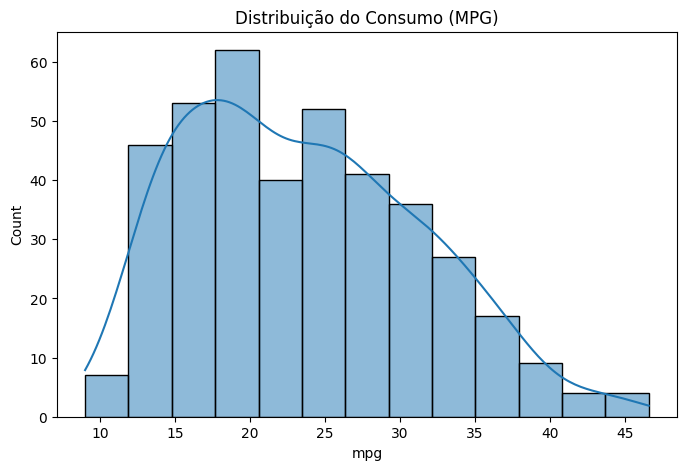

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['mpg'], kde=True)
plt.title('Distribuição do Consumo (MPG)')
plt.show() #histograma simples para o consumo de Milhas por Galão (EUA)

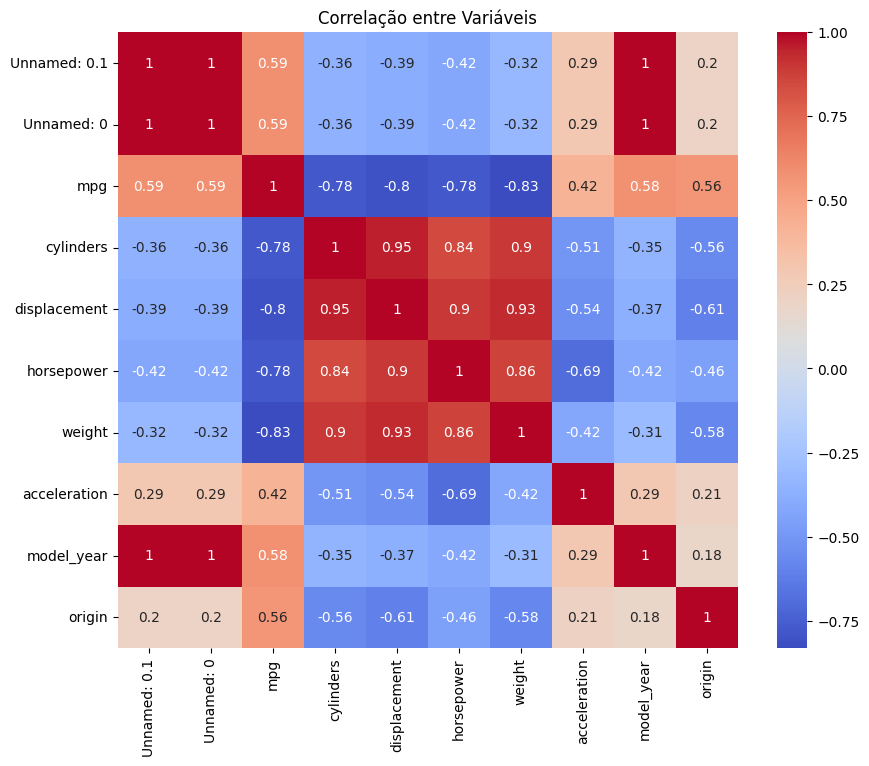

In [40]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlação entre Variáveis')
plt.show() #Mapa de calor para correlação entre todos os dados no dataset (diagonais sempre como 1 pois é o mesmo tipo de dado)

In [41]:
df['Categoria_Consumo'] = pd.cut(
    df['mpg'],
    bins=[0, 20, 30, 100],
    labels=['Alto Consumo', 'Médio', 'Econômico']
)

df['Categoria_Consumo'].value_counts() #classificação de se sào economicos ou não

Categoria_Consumo
Alto Consumo    160
Médio           153
Econômico        85
Name: count, dtype: int64

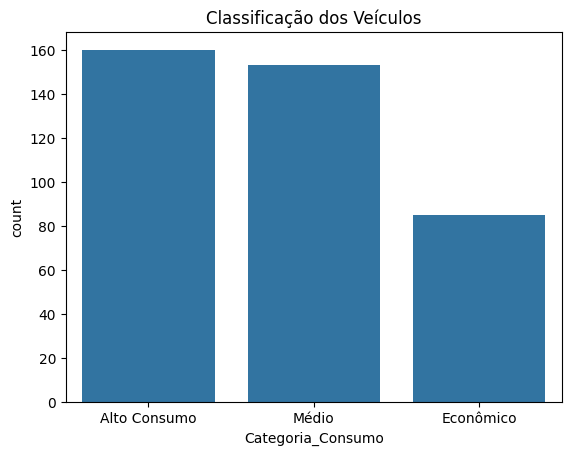

In [42]:
sns.countplot(
    data=df,
    x='Categoria_Consumo'
)

plt.title('Classificação dos Veículos')
plt.show() #distribuição por categoria

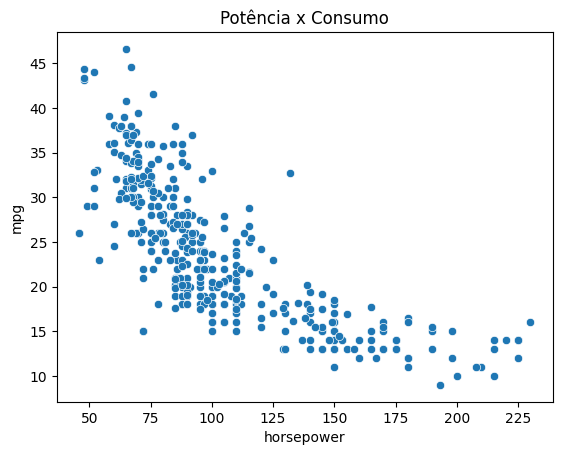

In [43]:
sns.scatterplot(
    data=df,
    x='horsepower',
    y='mpg'
)

plt.title('Potência x Consumo')
plt.show() #o mais importante, a quantidade de combustivel gasto pela potencia do carro, outlier nos 125hp.